             group_label  total_utterances  imperative_utterances  \
0  Female / Bechdel Fail              1494                     73   
1  Female / Bechdel Pass             43201                   1679   
2    Male / Bechdel Fail              8607                    439   
3    Male / Bechdel Pass             83760                   4063   

   imperatives_per_1000  
0             48.862115  
1             38.864841  
2             51.004996  
3             48.507641  


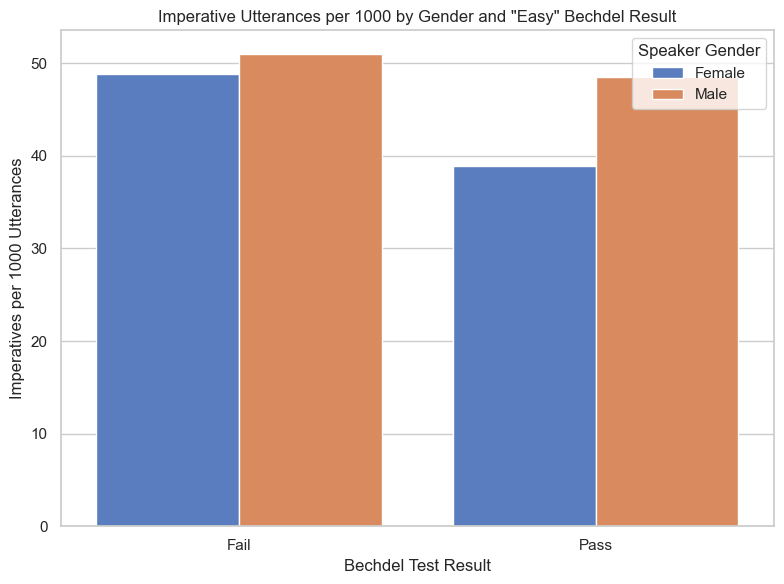

In [5]:
# Results for EASY Bechdel Test

import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

nlp = spacy.load("en_core_web_sm")


def is_likely_imperative(sentence):
    doc = nlp(str(sentence))  # input has to be a string
    if not doc:
        return False

    first = doc[0]
    if first.pos_ == "VERB" and first.tag_ == "VB":
        subjects = [tok for tok in doc if tok.dep_ == "nsubj"]
        if any(tok.text.lower() == "i" for tok in subjects):
            return False
        return True

    return False


df = pd.read_csv("df_binarized_easy.csv") 


df = df[df['gender'].isin(['m', 'f']) & df['text'].notnull() & df['bechdel_score'].notnull()]

df['bechdel_pass'] = df['bechdel_score'] == 1

df['is_imperative'] = df['text'].apply(is_likely_imperative)

grouped = df.groupby(['gender', 'bechdel_pass'])

total_by_group = grouped.size()
imperatives_by_group = df[df['is_imperative']].groupby(['gender', 'bechdel_pass']).size()

summary = pd.DataFrame({
    'total_utterances': total_by_group,
    'imperative_utterances': imperatives_by_group
}).fillna(0)

summary['imperatives_per_1000'] = summary['imperative_utterances'] / summary['total_utterances'] * 1000

summary.index = summary.index.set_names(['gender', 'bechdel_pass'])
summary = summary.reset_index()

summary['group_label'] = summary.apply(
    lambda row: f"{'Female' if row['gender'] == 'f' else 'Male'} / Bechdel {'Pass' if row['bechdel_pass'] else 'Fail'}", axis=1
)

print(summary[['group_label', 'total_utterances', 'imperative_utterances', 'imperatives_per_1000']])

plot_df = summary.copy()

plot_df['Bechdel'] = plot_df['bechdel_pass'].map({True: 'Pass', False: 'Fail'})
plot_df['Gender'] = plot_df['gender'].map({'f': 'Female', 'm': 'Male'})

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=plot_df,
    x='Bechdel',
    y='imperatives_per_1000',
    hue='Gender',
    palette='muted'
)
plt.title('Imperative Utterances per 1000 by Gender and "Easy" Bechdel Result')
plt.ylabel('Imperatives per 1000 Utterances')
plt.xlabel('Bechdel Test Result')

plt.legend(title='Speaker Gender')
plt.tight_layout()
plt.show()

             group_label  total_utterances  imperative_utterances  \
0  Female / Bechdel Fail              9457                    362   
1  Female / Bechdel Pass             35238                   1390   
2    Male / Bechdel Fail             37547                   1841   
3    Male / Bechdel Pass             54820                   2661   

   imperatives_per_1000  
0             38.278524  
1             39.446053  
2             49.031880  
3             48.540679  


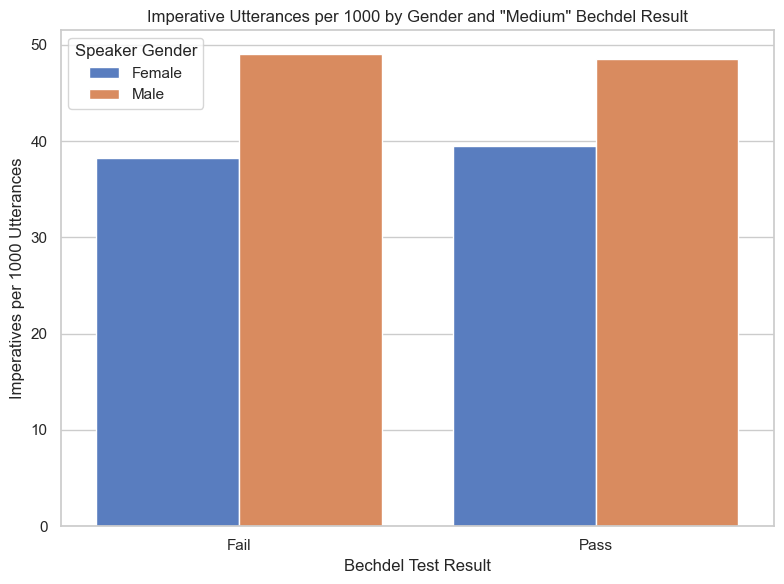

In [6]:
# Results for MEDIUM Bechdel Test

import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

nlp = spacy.load("en_core_web_sm")


def is_likely_imperative(sentence):
    doc = nlp(str(sentence))  # input has to be a string
    if not doc:
        return False

    first = doc[0]
    if first.pos_ == "VERB" and first.tag_ == "VB":
        subjects = [tok for tok in doc if tok.dep_ == "nsubj"]
        if any(tok.text.lower() == "i" for tok in subjects):
            return False
        return True

    return False


df = pd.read_csv("df_binarized_medium.csv") 


df = df[df['gender'].isin(['m', 'f']) & df['text'].notnull() & df['bechdel_score'].notnull()]

df['bechdel_pass'] = df['bechdel_score'] == 1

df['is_imperative'] = df['text'].apply(is_likely_imperative)

grouped = df.groupby(['gender', 'bechdel_pass'])

total_by_group = grouped.size()
imperatives_by_group = df[df['is_imperative']].groupby(['gender', 'bechdel_pass']).size()

summary = pd.DataFrame({
    'total_utterances': total_by_group,
    'imperative_utterances': imperatives_by_group
}).fillna(0)

summary['imperatives_per_1000'] = summary['imperative_utterances'] / summary['total_utterances'] * 1000

summary.index = summary.index.set_names(['gender', 'bechdel_pass'])
summary = summary.reset_index()

summary['group_label'] = summary.apply(
    lambda row: f"{'Female' if row['gender'] == 'f' else 'Male'} / Bechdel {'Pass' if row['bechdel_pass'] else 'Fail'}", axis=1
)

print(summary[['group_label', 'total_utterances', 'imperative_utterances', 'imperatives_per_1000']])

plot_df = summary.copy()

plot_df['Bechdel'] = plot_df['bechdel_pass'].map({True: 'Pass', False: 'Fail'})
plot_df['Gender'] = plot_df['gender'].map({'f': 'Female', 'm': 'Male'})

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=plot_df,
    x='Bechdel',
    y='imperatives_per_1000',
    hue='Gender',
    palette='muted'
)
plt.title('Imperative Utterances per 1000 by Gender and "Medium" Bechdel Result')
plt.ylabel('Imperatives per 1000 Utterances')
plt.xlabel('Bechdel Test Result')

plt.legend(title='Speaker Gender')
plt.tight_layout()
plt.show()

             group_label  total_utterances  imperative_utterances  \
0  Female / Bechdel Fail             15459                    603   
1  Female / Bechdel Pass             29236                   1149   
2    Male / Bechdel Fail             52201                   2591   
3    Male / Bechdel Pass             40166                   1911   

   imperatives_per_1000  
0             39.006404  
1             39.300862  
2             49.635064  
3             47.577553  


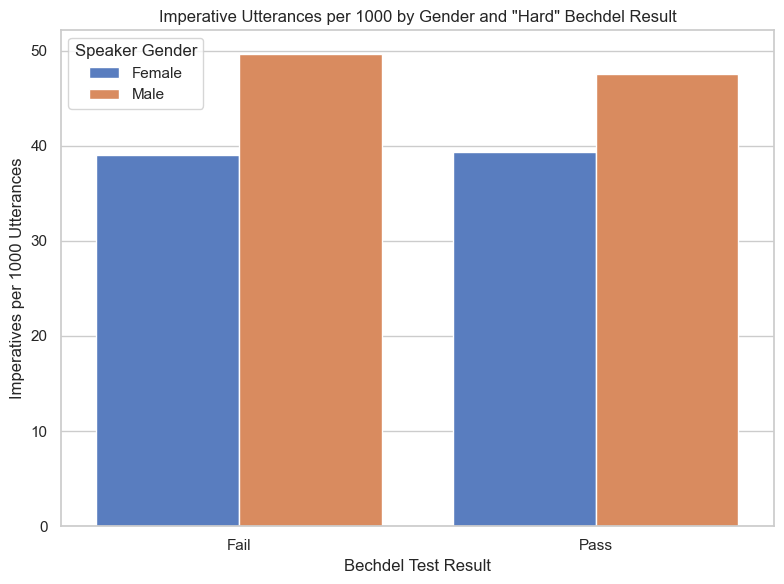

In [7]:
# Results for HARD Bechdel Test

import pandas as pd
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

nlp = spacy.load("en_core_web_sm")


def is_likely_imperative(sentence):
    doc = nlp(str(sentence))  # input has to be a string
    if not doc:
        return False

    first = doc[0]
    if first.pos_ == "VERB" and first.tag_ == "VB":
        subjects = [tok for tok in doc if tok.dep_ == "nsubj"]
        if any(tok.text.lower() == "i" for tok in subjects):
            return False
        return True

    return False


df = pd.read_csv("df_binarized_hard.csv") 


df = df[df['gender'].isin(['m', 'f']) & df['text'].notnull() & df['bechdel_score'].notnull()]

df['bechdel_pass'] = df['bechdel_score'] == 1

df['is_imperative'] = df['text'].apply(is_likely_imperative)

grouped = df.groupby(['gender', 'bechdel_pass'])

total_by_group = grouped.size()
imperatives_by_group = df[df['is_imperative']].groupby(['gender', 'bechdel_pass']).size()

summary = pd.DataFrame({
    'total_utterances': total_by_group,
    'imperative_utterances': imperatives_by_group
}).fillna(0)

summary['imperatives_per_1000'] = summary['imperative_utterances'] / summary['total_utterances'] * 1000

summary.index = summary.index.set_names(['gender', 'bechdel_pass'])
summary = summary.reset_index()

summary['group_label'] = summary.apply(
    lambda row: f"{'Female' if row['gender'] == 'f' else 'Male'} / Bechdel {'Pass' if row['bechdel_pass'] else 'Fail'}", axis=1
)

print(summary[['group_label', 'total_utterances', 'imperative_utterances', 'imperatives_per_1000']])

plot_df = summary.copy()

plot_df['Bechdel'] = plot_df['bechdel_pass'].map({True: 'Pass', False: 'Fail'})
plot_df['Gender'] = plot_df['gender'].map({'f': 'Female', 'm': 'Male'})

sns.set(style="whitegrid")

plt.figure(figsize=(8, 6))
sns.barplot(
    data=plot_df,
    x='Bechdel',
    y='imperatives_per_1000',
    hue='Gender',
    palette='muted'
)
plt.title('Imperative Utterances per 1000 by Gender and "Hard" Bechdel Result')
plt.ylabel('Imperatives per 1000 Utterances')
plt.xlabel('Bechdel Test Result')

plt.legend(title='Speaker Gender')
plt.tight_layout()
plt.show()